# 1. Energy Consumption
* Energy consumption prediction,planing electric production
* Prediction future from past


In [1]:
import pandas as pd
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Plan 
 -  Data Load and Cleaning
 -  Resampling
 -  Sliding window
 -  Data Scaling
 -  LSTM
 -  Performance Analysis
 -  Future Prediction

# 2. Load data

In [2]:
data = pd.read_csv("household_power_consumption.txt",sep=";",parse_dates={"Datetime" : ["Date","Time"]},infer_datetime_format=True,na_values="?",low_memory = False)
data

C:\Users\PC\AppData\Local\Temp\ipykernel_5324\2482211420.py:1: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  data = pd.read_csv("household_power_consumption.txt",sep=";",parse_dates={"Datetime" : ["Date","Time"]},infer_datetime_format=True,na_values="?",low_memory = False)
C:\Users\PC\AppData\Local\Temp\ipykernel_5324\2482211420.py:1: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  data = pd.read_csv("household_power_consumption.txt",sep=";",parse_dates={"Datetime" : ["Date","Time"]},infer_datetime_format=True,na_values="?",low_memory = False)
C:\Users\PC\AppData\Local\Temp\ipykernel_5324\2482211420.py:1: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S f

,Datetime,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0
...,...,...,...,...,...,...,...,...
2075254,2010-11-26 20:58:00,0.946,0.000,240.43,4.0,0.0,0.0,0.0
2075255,2010-11-26 20:59:00,0.944,0.000,240.00,4.0,0.0,0.0,0.0
2075256,2010-11-26 21:00:00,0.938,0.000,239.82,3.8,0.0,0.0,0.0
2075257,2010-11-26 21:01:00,0.934,0.000,239.70,3.8,0.0,0.0,0.0


In [3]:
data.set_index("Datetime",inplace = True)

In [4]:
data.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [5]:
data.dtypes

Global_active_power      float64
Global_reactive_power    float64
Voltage                  float64
Global_intensity         float64
Sub_metering_1           float64
Sub_metering_2           float64
Sub_metering_3           float64
dtype: object

In [6]:
data["Global_active_power"] = pd.to_numeric(data["Global_active_power"],errors="coerce")

In [7]:
data = data.dropna(subset=["Global_active_power"])
data

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0
...,...,...,...,...,...,...,...
2010-11-26 20:58:00,0.946,0.000,240.43,4.0,0.0,0.0,0.0
2010-11-26 20:59:00,0.944,0.000,240.00,4.0,0.0,0.0,0.0
2010-11-26 21:00:00,0.938,0.000,239.82,3.8,0.0,0.0,0.0


In [8]:
data_hourly = data["Global_active_power"].resample("H").mean()
data_hourly.head()

C:\Users\PC\AppData\Local\Temp\ipykernel_5324\2905173019.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  data_hourly = data["Global_active_power"].resample("H").mean()


Datetime
2006-12-16 17:00:00    4.222889
2006-12-16 18:00:00    3.632200
2006-12-16 19:00:00    3.400233
2006-12-16 20:00:00    3.268567
2006-12-16 21:00:00    3.056467
Freq: h, Name: Global_active_power, dtype: float64

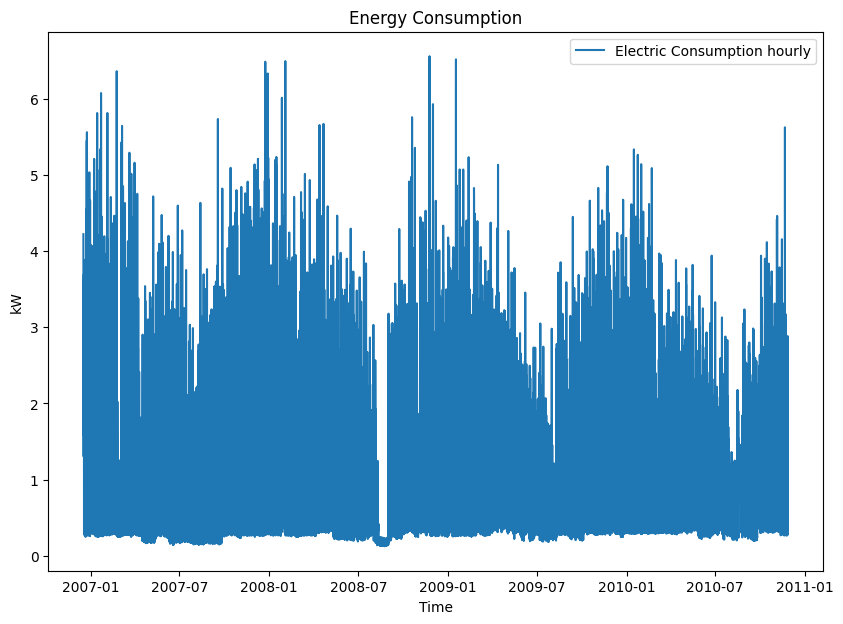

In [9]:
plt.figure(figsize = (10,7))
plt.plot(data_hourly,label = "Electric Consumption hourly")
plt.title("Energy Consumption")
plt.xlabel("Time")
plt.ylabel("kW")
plt.legend()
plt.show()

In [10]:
data_hourly.to_csv("data_hourly.csv",index = True)

# 3. Preprocessing

In [11]:
from sklearn.preprocessing import MinMaxScaler
import joblib

In [12]:
df = pd.read_csv("data_hourly.csv",index_col = 0,parse_dates = True)
df.head()

,Global_active_power
Datetime,
2006-12-16 17:00:00,4.222889
2006-12-16 18:00:00,3.632200
2006-12-16 19:00:00,3.400233
2006-12-16 20:00:00,3.268567
2006-12-16 21:00:00,3.056467


In [13]:
df.dropna(inplace=  True)
df.isnull().sum()

Global_active_power    0
dtype: int64

In [14]:
values = df.values.reshape(-1,1)
values

array([[4.22288889],
       [3.6322    ],
       [3.40023333],
       ...,
       [1.65933333],
       [1.1637    ],
       [0.93466667]], shape=(34168, 1))

In [15]:
scaler = MinMaxScaler()
scaled = scaler.fit_transform(values)
scaled

array([[0.63681623],
       [0.54504495],
       [0.50900588],
       ...,
       [0.2385342 ],
       [0.16153105],
       [0.12594772]], shape=(34168, 1))

In [16]:
joblib.dump(scaler,"scaler.save")

['scaler.save']

In [17]:
def create_sliding_window(data,window_size = 24):
    X,y = [],[]
    for i in range(len(data) - window_size):
        X.append(data[i:i + window_size])
        y.append(data[i + window_size])
    return np.array(X),np.array(y)

X,y = create_sliding_window(scaled)
X,y

(array([[[0.63681623],
         [0.54504495],
         [0.50900588],
         ...,
         [0.30585305],
         [0.44455608],
         [0.49747794]],
 
        [[0.54504495],
         [0.50900588],
         [0.48854974],
         ...,
         [0.44455608],
         [0.49747794],
         [0.51002092]],
 
        [[0.50900588],
         [0.48854974],
         [0.45559722],
         ...,
         [0.49747794],
         [0.51002092],
         [0.55512802]],
 
        ...,
 
        [[0.34280358],
         [0.23674752],
         [0.1893773 ],
         ...,
         [0.14665244],
         [0.24887621],
         [0.22519369]],
 
        [[0.23674752],
         [0.1893773 ],
         [0.17456084],
         ...,
         [0.24887621],
         [0.22519369],
         [0.2385342 ]],
 
        [[0.1893773 ],
         [0.17456084],
         [0.12941749],
         ...,
         [0.22519369],
         [0.2385342 ],
         [0.16153105]]], shape=(34144, 24, 1)),
 array([[0.51002092],
        [0.

In [18]:
split = int(len(X)*0.8)
X_train = X[:split]
X_test = X[split:]
y_train = y[:split]
y_test = y[split:]
X_train,X_test,y_train,y_test

(array([[[0.63681623],
         [0.54504495],
         [0.50900588],
         ...,
         [0.30585305],
         [0.44455608],
         [0.49747794]],
 
        [[0.54504495],
         [0.50900588],
         [0.48854974],
         ...,
         [0.44455608],
         [0.49747794],
         [0.51002092]],
 
        [[0.50900588],
         [0.48854974],
         [0.45559722],
         ...,
         [0.49747794],
         [0.51002092],
         [0.55512802]],
 
        ...,
 
        [[0.3560457 ],
         [0.26724531],
         [0.20257799],
         ...,
         [0.03946224],
         [0.03703857],
         [0.13171169]],
 
        [[0.26724531],
         [0.20257799],
         [0.21041865],
         ...,
         [0.03703857],
         [0.13171169],
         [0.28446472]],
 
        [[0.20257799],
         [0.21041865],
         [0.20575258],
         ...,
         [0.13171169],
         [0.28446472],
         [0.22900526]]], shape=(27315, 24, 1)),
 array([[[0.21041865],
         [

# 3. LSTM Model

In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM,Dense
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.losses import MeanSquaredError

In [20]:
model = Sequential()
model.add(LSTM(
    64, # lstm cell
    activation = "tanh",
    input_shape = (X_train.shape[1],X_train.shape[2])
))

model.add(Dense(1))

model.compile(optimizer = "adam",
              loss  = MeanSquaredError(),
              metrics = ["mae"])

early_stop = EarlyStopping(monitor = "val_loss",
                           patience = 5,
                           restore_best_weights=True)
history = model.fit(X_train,y_train,
                    validation_data = (X_test,y_test),
                    epochs= 10,
                    batch_size = 32,
                    callbacks = [early_stop],
                    verbose = 1)


c:\Users\PC\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
854/854 ━━━━━━━━━━━━━━━━━━━━ 20s 19ms/step - loss: 0.0115 - mae: 0.0782 - val_loss: 0.0073 - val_mae: 0.0592
Epoch 2/10
854/854 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - loss: 0.0093 - mae: 0.0681 - val_loss: 0.0067 - val_mae: 0.0579
Epoch 3/10
854/854 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - loss: 0.0089 - mae: 0.0656 - val_loss: 0.0064 - val_mae: 0.0554
Epoch 4/10
854/854 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - loss: 0.0088 - mae: 0.0649 - val_loss: 0.0067 - val_mae: 0.0593
Epoch 5/10
854/854 ━━━━━━━━━━━━━━━━━━━━ 16s 18ms/step - loss: 0.0088 - mae: 0.0649 - val_loss: 0.0064 - val_mae: 0.0568
Epoch 6/10
854/854 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - loss: 0.0087 - mae: 0.0644 - val_loss: 0.0064 - val_mae: 0.0557
Epoch 7/10
854/854 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step - loss: 0.0087 - mae: 0.0644 - val_loss: 0.0066 - val_mae: 0.0563
Epoch 8/10
854/854 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step - loss: 0.0087 - mae: 0.0643 - val_loss: 0.0063 - val_mae: 0.0558
Epoch 9/10
854/854 ━━━━━━━━━━━━━━━━━━━━ 

<Axes: >

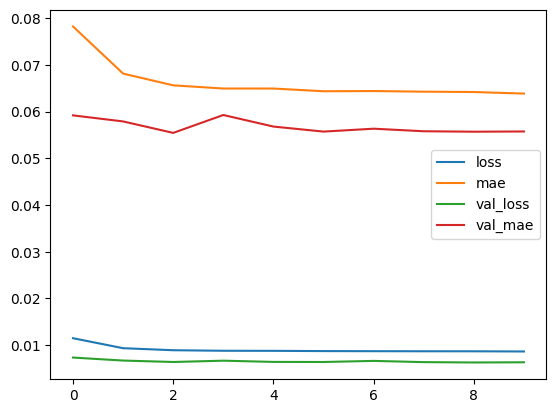

In [21]:
pd.DataFrame(history.history).plot()

In [22]:
model.save("lstm_model.h5")

# 4. Evaluate Model

In [23]:
y_pred = model.predict(X_test)
y_pred

214/214 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step


array([[0.2331239 ],
       [0.18880972],
       [0.1906963 ],
       ...,
       [0.27085117],
       [0.24963856],
       [0.15803471]], shape=(6829, 1), dtype=float32)

In [24]:
y_pred_inverse = scaler.inverse_transform(y_pred)
y_pred_inverse

array([[1.6245097],
       [1.33928  ],
       [1.351423 ],
       ...,
       [1.8673426],
       [1.7308068],
       [1.1411957]], shape=(6829, 1), dtype=float32)

In [25]:
y_true = scaler.inverse_transform(y_test)
y_true

array([[1.42496667],
       [1.43766667],
       [1.79663333],
       ...,
       [1.65933333],
       [1.1637    ],
       [0.93466667]], shape=(6829, 1))

In [27]:
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_true,y_pred_inverse)
print(mae)

0.3585041871549301


In [28]:
rmse = np.sqrt(mae)
rmse

np.float64(0.5987521917746357)

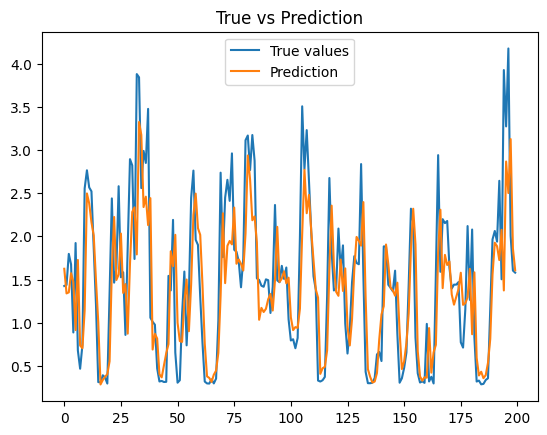

In [30]:
plt.figure()
plt.plot(y_true[:200],label = "True values")
plt.plot(y_pred_inverse[:200],label = "Prediction")
plt.title("True vs Prediction")
plt.legend()
plt.show()

In [31]:
data_hourly.head()

Datetime
2006-12-16 17:00:00    4.222889
2006-12-16 18:00:00    3.632200
2006-12-16 19:00:00    3.400233
2006-12-16 20:00:00    3.268567
2006-12-16 21:00:00    3.056467
Freq: h, Name: Global_active_power, dtype: float64

In [32]:
past = data_hourly[-48:].copy()
past.head()

Datetime
2010-11-24 22:00:00    0.422100
2010-11-24 23:00:00    0.353100
2010-11-25 00:00:00    0.303467
2010-11-25 01:00:00    0.289667
2010-11-25 02:00:00    0.266367
Freq: h, Name: Global_active_power, dtype: float64

In [33]:
last_24 = past[:24].values
last_24

array([0.4221    , 0.3531    , 0.30346667, 0.28966667, 0.26636667,
       0.33573333, 0.37706667, 0.88053333, 0.9632    , 2.62713333,
       1.6294    , 1.2577    , 0.64546667, 1.02806667, 0.49973333,
       0.35623333, 0.30066667, 0.333     , 0.5418    , 1.4801    ,
       2.2116    , 2.33046667, 1.64783333, 1.34293333])

In [34]:
real_24 = past[24:].values
real_24

array([1.24756667, 0.957     , 0.2943    , 0.281     , 0.27343333,
       0.29836667, 0.31403333, 0.28256667, 1.00876667, 2.88393333,
       1.9993    , 1.84996667, 1.35276667, 1.3389    , 1.4902    ,
       1.61293333, 1.40776667, 0.87643333, 1.06793333, 1.7259    ,
       1.57346667, 1.65933333, 1.1637    , 0.93466667])

In [36]:
forecast = X_test[-1].copy()
forecast

array([[0.1893773 ],
       [0.17456084],
       [0.12941749],
       [0.02645834],
       [0.02439201],
       [0.02321643],
       [0.02709015],
       [0.02952417],
       [0.02463541],
       [0.13746012],
       [0.4287919 ],
       [0.29135249],
       [0.26815159],
       [0.19090504],
       [0.18875067],
       [0.21225712],
       [0.23132535],
       [0.19945001],
       [0.1169004 ],
       [0.14665244],
       [0.24887621],
       [0.22519369],
       [0.2385342 ],
       [0.16153105]])

In [39]:
future_predictions = []
for _ in range(24):
    input_3d = forecast.reshape(1,forecast.shape[0],1)
    next_scaled  = model.predict(input_3d)[0]
    next_value = scaler.inverse_transform(next_scaled.reshape(1,-1))[0][0]
    future_predictions.append(next_value)
    forecast = np.vstack((forecast[1:],next_scaled.reshape(1,1)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step


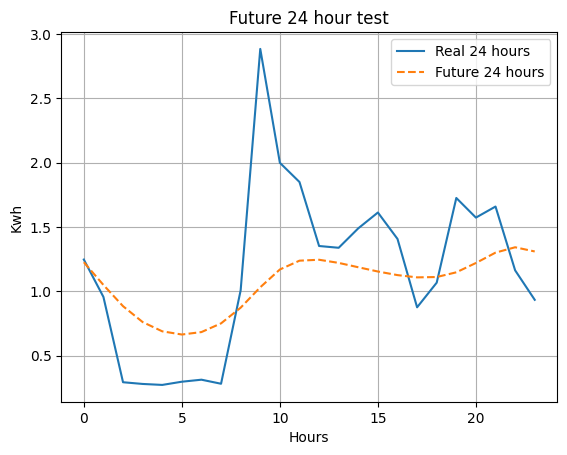

In [40]:
plt.figure()
plt.plot(real_24.flatten(),label = "Real 24 hours")
plt.plot(future_predictions,label ="Future 24 hours",linestyle = "--")
plt.title("Future 24 hour test")
plt.xlabel("Hours")
plt.ylabel("Kwh")
plt.grid()
plt.legend()
plt.show()